## 1. Setup and Load Factor Panel

In [1]:
import sys
sys.path.append(r"D:\Quant\Multi_factor_project")
from config import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False

factor_panel = pd.read_parquet(f"{DATA_CLEAN}/factor_panel.parquet")
print(f"OK factor_panel loaded successfully: {factor_panel.shape}")
print(factor_panel.columns.tolist())

factor_cols_std = ['mom_12m_std', 'mom_1m_std', 'roe_ttm_std', 'net_margin_std', 'pe_ttm_std', 'pb_std']

✓ factor_panel 读取成功: (35255, 17)
['ts_code', 'month', 'adj_close', 'ret_1m', 'mom_12m', 'mom_1m', 'roe_ttm', 'net_margin', 'pe_ttm', 'pb', 'industry_name', 'mom_12m_std', 'mom_1m_std', 'roe_ttm_std', 'net_margin_std', 'pe_ttm_std', 'pb_std']


## 2. Rank IC Analysis

Compute the monthly Spearman rank correlation ("Rank IC") between each standardized factor and the subsequent month's return, guarding against non-consecutive-month gaps in the panel, and summarize with IC mean, ICIR, t-statistic, p-value, and win rate.

**Note on timing alignment:** please double-check the intended lag convention here — see the review notes below the notebook for details.

In [2]:
def calc_rank_ic(factor_panel, factor_cols):
    \"\"\"
    Compute the monthly Rank IC for each factor.
    IC = Spearman correlation between the factor value ranking and next month's return ranking.
    \"\"\"
    df = factor_panel.copy()
    df = df.sort_values(['ts_code', 'month'])
    df['next_ret'] = df.groupby('ts_code')['ret_1m'].shift(-1)
    df['next_month'] = df.groupby('ts_code')['month'].shift(-1)

    # Keep only records where "the next row is exactly the following calendar month"
    # (works whether 'month' is a Period or a Timestamp)
    gap = (df['next_month'].dt.to_period('M') - df['month'].dt.to_period('M')).apply(lambda x: x.n if pd.notna(x) else np.nan)
    df.loc[gap != 1, 'next_ret'] = np.nan
    ic_results = {}
    for factor in factor_cols:
        monthly_ic = []
        for month, group in df.groupby('month'):
            valid = group[[factor, 'next_ret']].dropna()
            if len(valid) < 10:
                continue
            ic, _ = stats.spearmanr(valid[factor], valid['next_ret'])
            monthly_ic.append({'month': month, 'ic': ic})
        ic_results[factor] = pd.DataFrame(monthly_ic)
    
    return ic_results

ic_results = calc_rank_ic(factor_panel, factor_cols_std)

print("IC analysis results by factor:\n")
summary_rows = []
for factor, ic_df in ic_results.items():
    ic_mean = ic_df['ic'].mean()
    ic_std = ic_df['ic'].std()
    icir = ic_mean / ic_std if ic_std != 0 else np.nan
    t_stat, p_value = stats.ttest_1samp(ic_df['ic'].dropna(), 0)
    win_rate = (ic_df['ic'] > 0).mean()
    
    summary_rows.append({
        'factor': factor, 'ic_mean': ic_mean, 'ic_std': ic_std,
        'icir': icir, 't_stat': t_stat, 'p_value': p_value, 'win_rate': win_rate
    })
    
    print(f"{factor}:")
    print(f"  IC mean={ic_mean:.4f}  ICIR={icir:.4f}  t-stat={t_stat:.2f}  p-value={p_value:.4f}  win rate={win_rate*100:.1f}%\n")

ic_summary = pd.DataFrame(summary_rows).sort_values('icir', ascending=False)
print("=== Sorted by ICIR ===")
print(ic_summary.to_string(index=False))
# Appended at the end of this cell: persist the IC results
ic_all = pd.DataFrame({
    f: df.set_index('month')['ic'] for f, df in ic_results.items()
})
ic_all.to_parquet(f"{DATA_CLEAN}/ic_results.parquet")

# Also save the summary table while we're at it
ic_summary.to_parquet(f"{DATA_CLEAN}/ic_summary.parquet")
print("OK IC results saved")

各因子 IC 分析结果：

mom_12m_std:
  IC均值=0.0405  ICIR=0.2675  t值=2.74  p值=0.0072  胜率=61.0%

mom_1m_std:
  IC均值=0.0022  ICIR=0.0186  t值=0.20  p值=0.8411  胜率=55.6%

roe_ttm_std:
  IC均值=0.0186  ICIR=0.1703  t值=1.83  p值=0.0692  胜率=56.0%

net_margin_std:
  IC均值=0.0048  ICIR=0.0628  t值=0.68  p值=0.5003  胜率=49.1%

pe_ttm_std:
  IC均值=0.0437  ICIR=0.3569  t值=3.88  p值=0.0002  胜率=63.6%

pb_std:
  IC均值=0.0317  ICIR=0.2352  t值=2.56  p值=0.0119  胜率=56.8%

=== 按ICIR排序 ===
        factor     IC均值    IC标准差     ICIR       t值       p值     IC胜率
    pe_ttm_std 0.043668 0.122368 0.356861 3.876503 0.000175 0.635593
   mom_12m_std 0.040487 0.151337 0.267528 2.741347 0.007204 0.609524
        pb_std 0.031678 0.134677 0.235217 2.555114 0.011898 0.567797
   roe_ttm_std 0.018608 0.109245 0.170333 1.834539 0.069159 0.560345
net_margin_std 0.004841 0.077116 0.062777 0.676124 0.500319 0.491379
    mom_1m_std 0.002166 0.116613 0.018577 0.200937 0.841100 0.555556
✓ IC结果已保存


## 3. IC Heatmap

Visualize quarterly-averaged Rank IC across factors and time to spot regime shifts in factor efficacy.

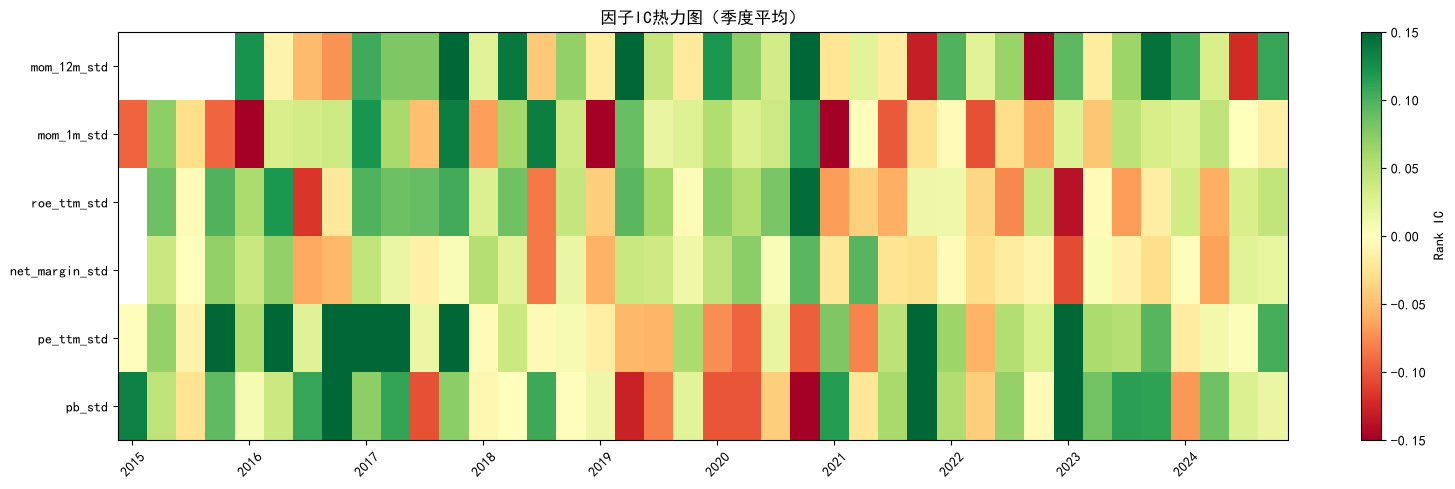

In [3]:
def plot_ic_heatmap(ic_results):
    ic_matrix = pd.DataFrame({
        factor: ic_df.set_index('month')['ic'] 
        for factor, ic_df in ic_results.items()
    })
    ic_matrix_q = ic_matrix.resample('QE').mean()
    
    fig, ax = plt.subplots(figsize=(16, 5))
    im = ax.imshow(ic_matrix_q.T.values, aspect='auto', cmap='RdYlGn', vmin=-0.15, vmax=0.15)
    
    ax.set_yticks(range(len(ic_matrix_q.columns)))
    ax.set_yticklabels(ic_matrix_q.columns)
    ax.set_xticks(range(0, len(ic_matrix_q.index), 4))
    ax.set_xticklabels([d.strftime('%Y') for d in ic_matrix_q.index[::4]], rotation=45)
    
    plt.colorbar(im, label='Rank IC')
    plt.title('Factor IC Heatmap (Quarterly Average)')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/plots/ic_heatmap.png", dpi=150)
    plt.show()

plot_ic_heatmap(ic_results)

## 4. Quantile Backtest

Sort stocks into quintiles by factor value each month and examine the monotonicity of subsequent-month returns across groups, using the same next-month alignment logic as the IC analysis.

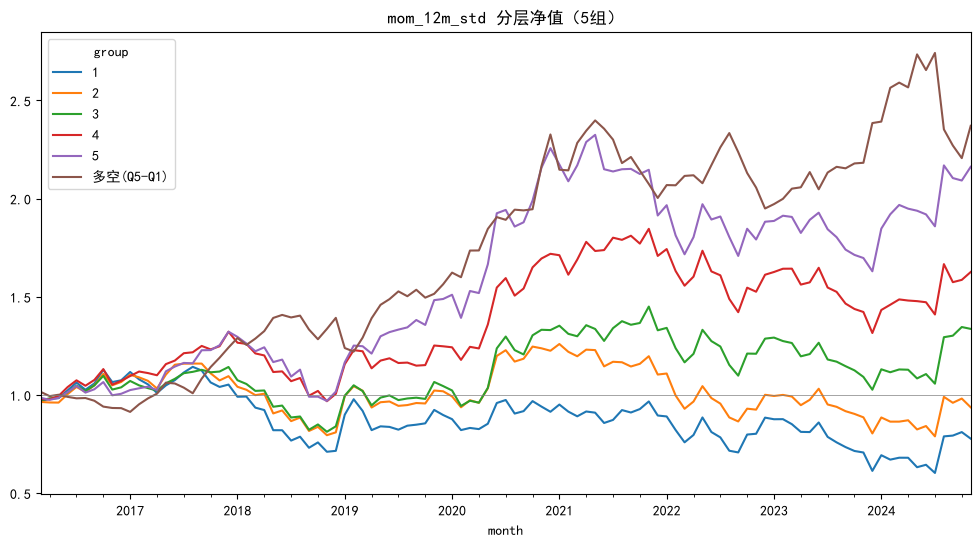

mom_12m_std: 多空年化 10.9%，各组月均收益：
group
1           -0.0004
2            0.0009
3            0.0041
4            0.0058
5            0.0087
多空(Q5-Q1)    0.0091
dtype: float64


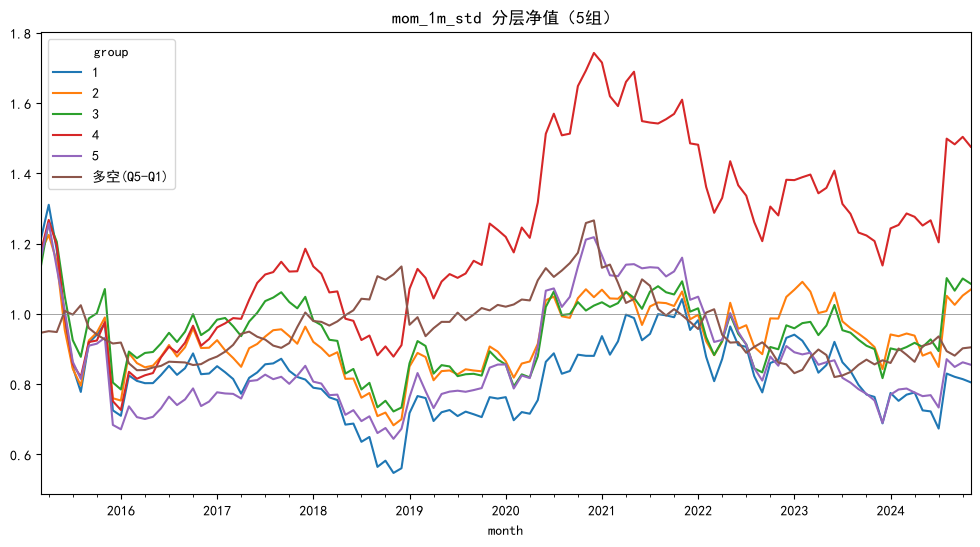

mom_1m_std: 多空年化 -0.4%，各组月均收益：
group
1            0.0009
2            0.0027
3            0.0027
4            0.0053
5            0.0006
多空(Q5-Q1)   -0.0003
dtype: float64


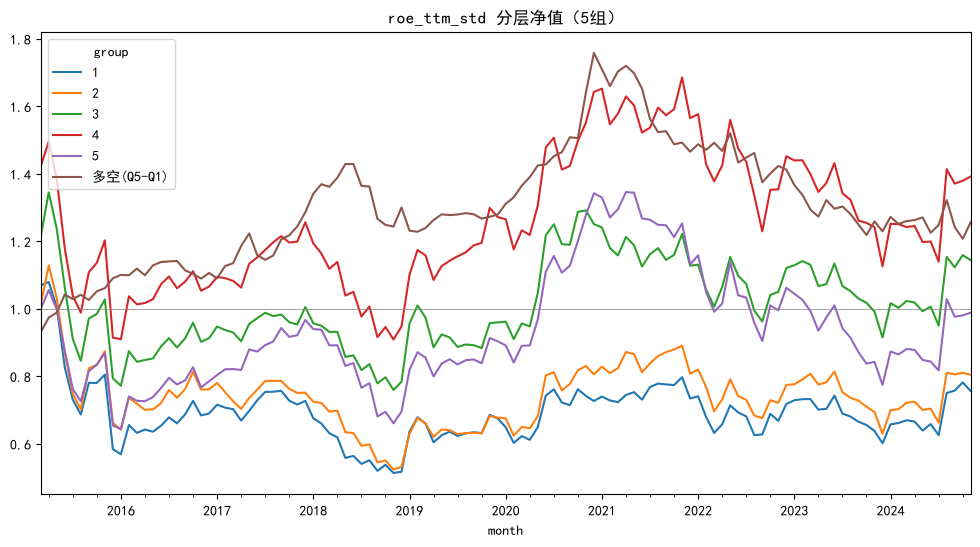

roe_ttm_std: 多空年化 2.8%，各组月均收益：
group
1           -0.0003
2            0.0002
3            0.0033
4            0.0053
5            0.0020
多空(Q5-Q1)    0.0024
dtype: float64


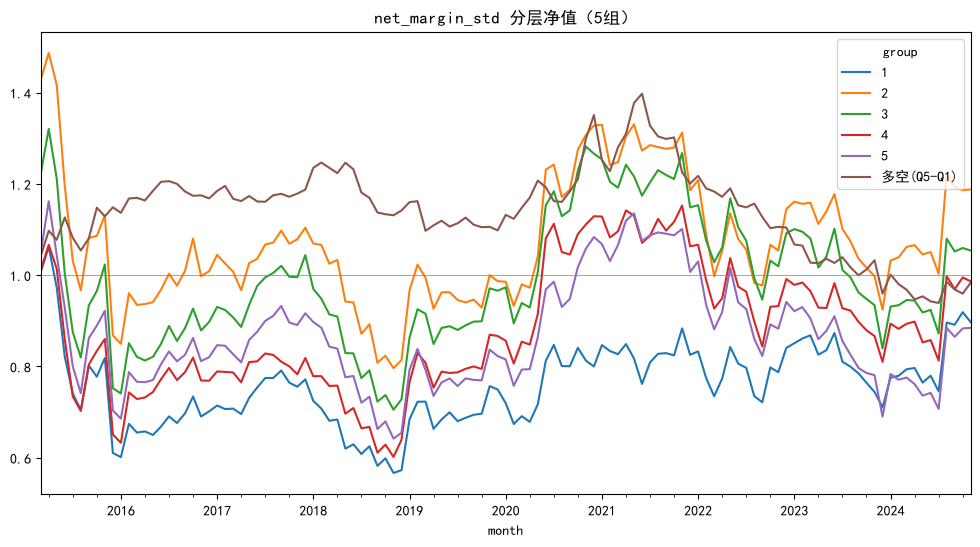

net_margin_std: 多空年化 0.2%，各组月均收益：
group
1            0.0009
2            0.0040
3            0.0028
4            0.0019
5            0.0011
多空(Q5-Q1)    0.0002
dtype: float64


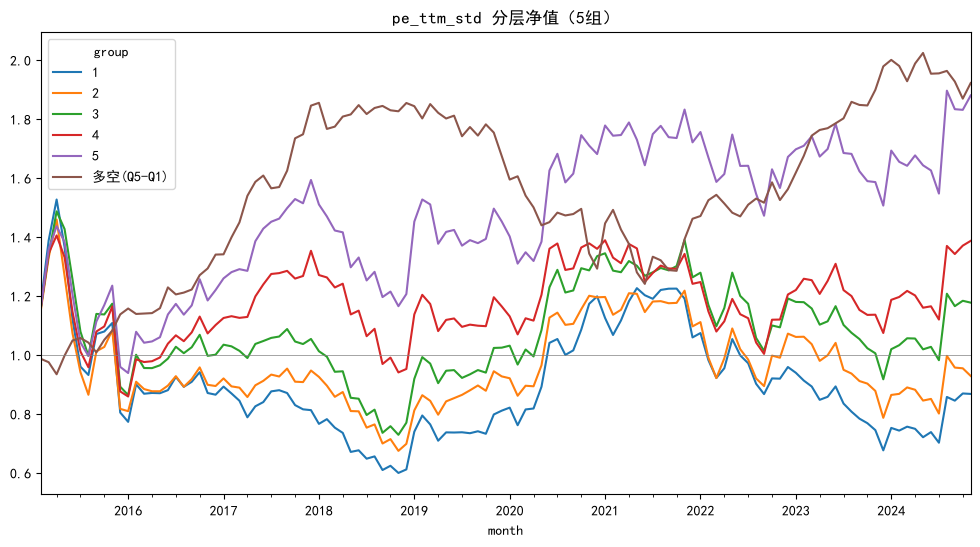

pe_ttm_std: 多空年化 7.3%，各组月均收益：
group
1            0.0013
2            0.0017
3            0.0036
4            0.0048
5            0.0074
多空(Q5-Q1)    0.0061
dtype: float64


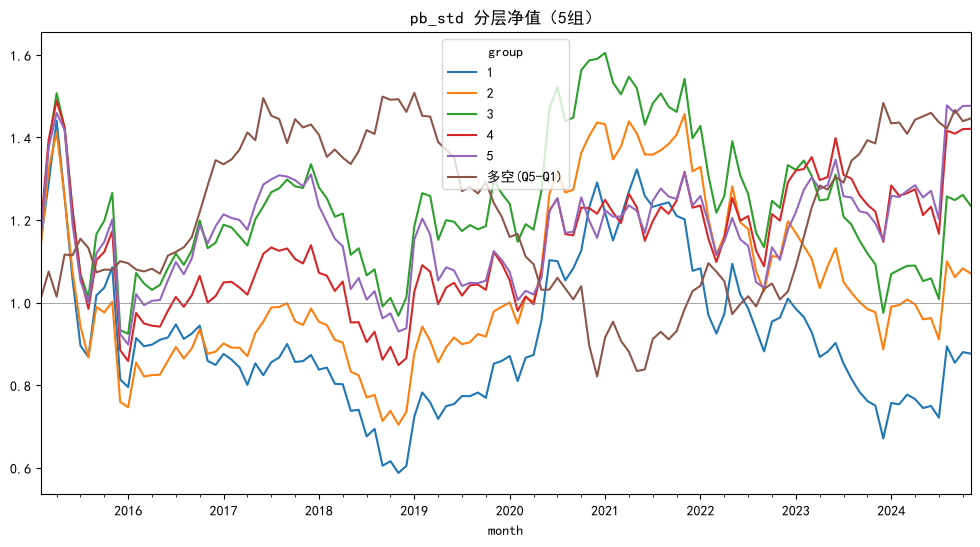

pb_std: 多空年化 4.6%，各组月均收益：
group
1            0.0014
2            0.0028
3            0.0041
4            0.0051
5            0.0053
多空(Q5-Q1)    0.0039
dtype: float64


In [9]:
def quantile_backtest(factor_panel, factor, n_groups=5):
    \"\"\"Sort stocks into quantiles by factor value and examine next month's return by group.\"\"\"
    df = factor_panel.copy()
    df = df.sort_values(['ts_code', 'month'])
    df['next_ret'] = df.groupby('ts_code')['ret_1m'].shift(-1)
    df['next_month'] = df.groupby('ts_code')['month'].shift(-1)
    gap = (df['next_month'].dt.to_period('M') - df['month'].dt.to_period('M')).apply(lambda x: x.n if pd.notna(x) else np.nan)
    df.loc[gap != 1, 'next_ret'] = np.nan
    df = df.dropna(subset=[factor, 'next_ret'])

    # Sort into groups by factor value each month (Q1 = lowest factor group, Q5 = highest)
    df['group'] = df.groupby('month')[factor].transform(
        lambda x: pd.qcut(x, n_groups, labels=False, duplicates='drop') + 1)

    # Equal-weighted monthly return per group
    group_ret = df.groupby(['month', 'group'])['next_ret'].mean().unstack()
    group_ret['long_short_Q5_Q1'] = group_ret[n_groups] - group_ret[1]

    # Cumulative NAV
    nav = (1 + group_ret).cumprod()
    nav.plot(figsize=(12, 6), title=f'{factor} Quantile NAV ({n_groups} groups)')
    plt.axhline(1, color='gray', lw=0.5)
    plt.show()

    # Monotonicity check: annualized long-short spread (best group minus worst group)
    ls_annual = group_ret['long_short_Q5_Q1'].mean() * 12
    print(f"{factor}: annualized long-short return {ls_annual*100:.1f}%, mean monthly return by group:")
    print(group_ret.mean().round(4))

for f in factor_cols_std:
    quantile_backtest(factor_panel, f)

## 5. Cross-Sectional Factor Correlation

Examine the average monthly cross-sectional Spearman correlation among factor values, to check for redundancy/collinearity before combining factors.

In [3]:
# ---- (1) Cross-sectional correlation of factor values (monthly average) ----
factors_use = ['mom_12m_std', 'pe_ttm_std', 'pb_std', 'roe_ttm_std']

cs_corrs = []
for month, group in factor_panel.groupby('month'):
    valid = group[factors_use].dropna()
    if len(valid) < 30:
        continue
    cs_corrs.append(valid.corr(method='spearman'))

avg_corr = sum(cs_corrs) / len(cs_corrs)
print("Cross-sectional factor correlation (averaged over 118 months):")
print(avg_corr.round(2))

因子值截面相关（118个月平均）：
             mom_12m_std  pe_ttm_std  pb_std  roe_ttm_std
mom_12m_std         1.00       -0.04   -0.24         0.19
pe_ttm_std         -0.04        1.00    0.49         0.31
pb_std             -0.24        0.49    1.00        -0.47
roe_ttm_std         0.19        0.31   -0.47         1.00


## 6. IC Time-Series Correlation

Examine whether factors' predictive power (IC) moves together over time, as a complementary collinearity diagnostic to the cross-sectional correlation above.

IC序列相关：
             mom_12m_std  pe_ttm_std  pb_std  roe_ttm_std
mom_12m_std         1.00        0.00   -0.32         0.47
pe_ttm_std          0.00        1.00    0.70         0.13
pb_std             -0.32        0.70    1.00        -0.53
roe_ttm_std         0.47        0.13   -0.53         1.00


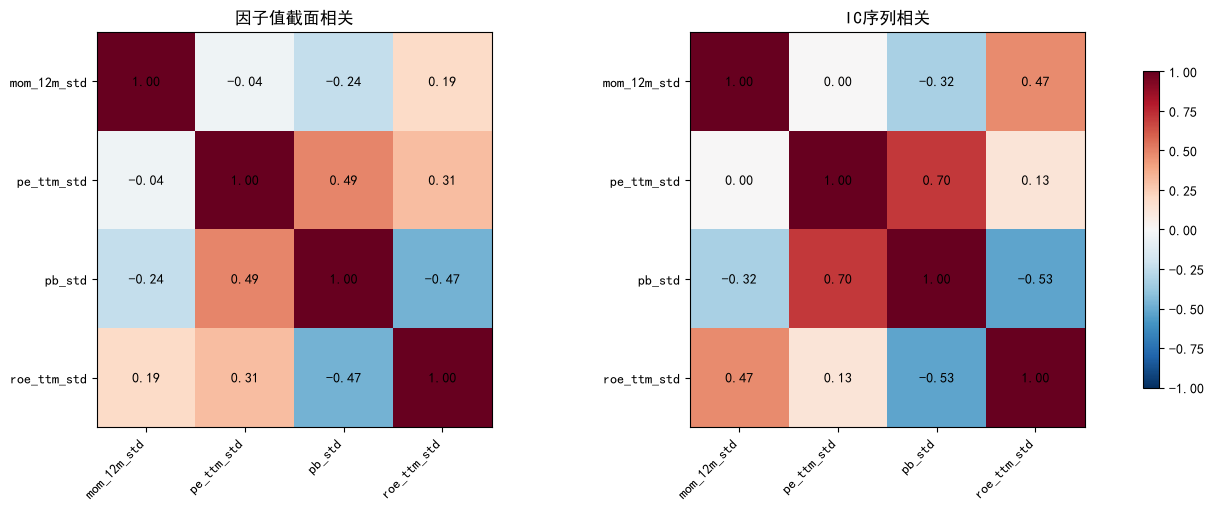

In [6]:
# ---- (2) Time-series correlation of IC series ----
ic_df_all = pd.DataFrame({
    f: ic_results[f].set_index('month')['ic'] for f in factors_use
})
ic_corr = ic_df_all.corr()
print("IC series correlation:")
print(ic_corr.round(2))

# Plot a heatmap for a more intuitive view
fig, axes = plt.subplots(1, 2, figsize=(13, 5),constrained_layout=True)
for ax, mat, title in zip(axes, [avg_corr, ic_corr], ['Cross-Sectional Factor Correlation', 'IC Series Correlation']):
    im = ax.imshow(mat.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(mat))); ax.set_xticklabels(mat.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(mat))); ax.set_yticklabels(mat.index)
    for i in range(len(mat)):
        for j in range(len(mat)):
            ax.text(j, i, f'{mat.values[i,j]:.2f}', ha='center', va='center')
    ax.set_title(title)
plt.colorbar(im, ax=axes, shrink=0.8)
plt.show()

## 7. Composite Factor Construction

Combine PE_TTM and PB into a single value factor (using whichever is available when one is missing), then equal-weight momentum, value, and quality into a final composite score.

In [7]:
# Composite value factor (handling missing data: use whichever single factor is available)
factor_panel['value_std'] = factor_panel[['pe_ttm_std','pb_std']].mean(axis=1, skipna=True)
# Only truly missing if both are missing
factor_panel.loc[factor_panel[['pe_ttm_std','pb_std']].isna().all(axis=1), 'value_std'] = np.nan

# Final equal-weighted three-factor composite
factor_panel['composite'] = factor_panel[['mom_12m_std','value_std','roe_ttm_std']].mean(axis=1, skipna=True)
factor_panel.to_parquet(f"{DATA_CLEAN}/factor_panel.parquet")

## 8. Validate the Composite Factor

Re-run the IC and quantile-backtest diagnostics on the composite factor to confirm it improves on (or is at least competitive with) its individual components.

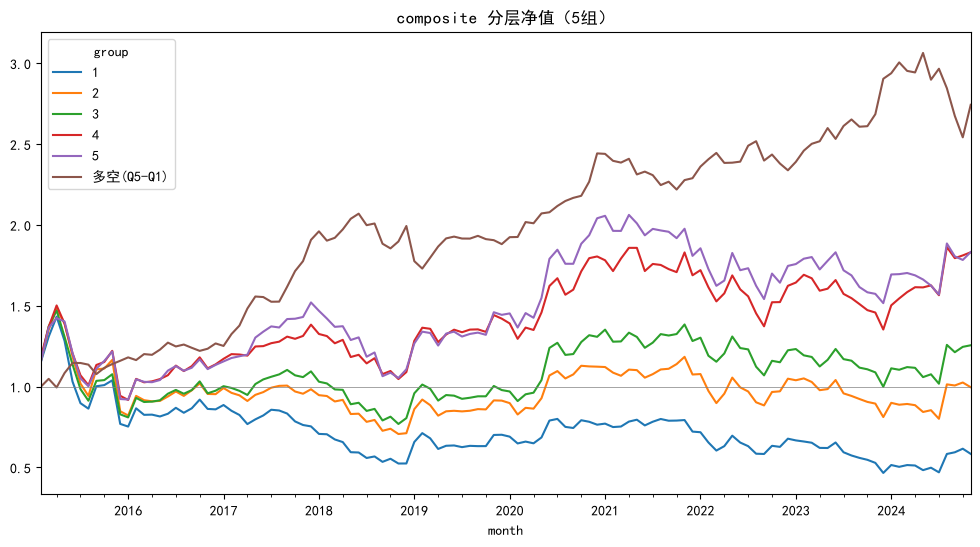

composite: 多空年化 11.0%，各组月均收益：
group
1           -0.0020
2            0.0024
3            0.0042
4            0.0071
5            0.0071
多空(Q5-Q1)    0.0091
dtype: float64


In [10]:
calc_rank_ic(factor_panel, ['mom_12m_std', 'value_std', 'roe_ttm_std'])
calc_rank_ic(factor_panel, ['composite'])
quantile_backtest(factor_panel, 'composite')